# Notebook 1: Data Acquisition & Exploratory Data Analysis
## Market Risk Engine — Multi-Asset Portfolio

**Objective:** Pull a realistic multi-asset trading book from Yahoo Finance and macro risk factors from FRED. Compute log returns, rolling statistics, and analyze correlation structure.

**Assets:**
- SPY (US Equities)
- GLD (Gold)
- EEM (Emerging Markets)
- EURUSD=X (FX)
- CL=F (Crude Oil)

**Macro Factors (FRED):**
- VIX (Volatility Index)
- 10Y Treasury Yield (DGS10)
- Investment Grade Credit Spread (BAMLC0A0CM)


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

# ── Path Configuration ──────────────────────────────────────────────────────
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
DATA_DIR = os.path.join(BASE_DIR, 'data')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print(f'BASE_DIR: {BASE_DIR}')
print(f'DATA_DIR: {DATA_DIR}')

BASE_DIR: c:\Users\amuya\OneDrive\Desktop\My Portfolio\market_risk_engine
DATA_DIR: c:\Users\amuya\OneDrive\Desktop\My Portfolio\market_risk_engine\data


In [2]:
# ── 1. Download Asset Price Data ─────────────────────────────────────────────
ASSETS = {
    'SPY':    'US Equities (S&P 500)',
    'GLD':    'Gold',
    'EEM':    'Emerging Markets',
    'EURUSD=X': 'EUR/USD FX',
    'CL=F':   'Crude Oil'
}

START_DATE = '2005-01-01'
END_DATE   = '2026-03-31'

print('Downloading asset prices...')
raw_prices = yf.download(
    list(ASSETS.keys()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)['Close']

# Clean column names
raw_prices.columns = ['Crude_Oil', 'EEM', 'EURUSD', 'GLD', 'SPY']
raw_prices.dropna(how='all', inplace=True)
raw_prices.ffill(inplace=True)

print(f'Shape: {raw_prices.shape}')
print(f'Date range: {raw_prices.index[0].date()} to {raw_prices.index[-1].date()}')
raw_prices.head()

Shape: (5537, 5)
Date range: 2005-01-03 to 2026-03-30


,Crude_Oil,EEM,EURUSD,GLD,SPY
Date,,,,,
2005-01-03,42.119999,14.562679,1.347001,43.020000,81.383728
2005-01-04,43.910000,14.114318,1.328198,42.740002,80.389259
2005-01-05,43.389999,13.941537,1.328004,42.669998,79.834557
2005-01-06,45.560001,13.932054,1.318305,42.150002,80.240402
2005-01-07,45.430000,13.959023,1.306097,41.840000,80.125412


In [3]:
# ── 2. Download FRED Macro Factors ────────────────────────────────────────────
# Using pandas_datareader as fallback for FRED data
try:
    import pandas_datareader.data as web
    print('Downloading FRED macro data...')
    
    vix   = web.DataReader('VIXCLS',     'fred', START_DATE, END_DATE)
    yield10 = web.DataReader('DGS10',    'fred', START_DATE, END_DATE)
    ig_spread = web.DataReader('BAMLC0A0CM', 'fred', START_DATE, END_DATE)
    
    macro = pd.concat([vix, yield10, ig_spread], axis=1)
    macro.columns = ['VIX', 'Yield_10Y', 'IG_Spread']
    macro.ffill(inplace=True)
    macro.dropna(inplace=True)
    print(f'FRED data shape: {macro.shape}')
except Exception as e:
    print(f'FRED download error: {e}')
    print('Creating synthetic macro factors...')
    idx = raw_prices.index
    np.random.seed(42)
    macro = pd.DataFrame({
        'VIX':       np.abs(20 + np.random.randn(len(idx)).cumsum() * 0.1),
        'Yield_10Y': np.abs(2.5 + np.random.randn(len(idx)).cumsum() * 0.01),
        'IG_Spread': np.abs(1.5 + np.random.randn(len(idx)).cumsum() * 0.005)
    }, index=idx)

macro.tail()

FRED download error: No module named 'pandas_datareader'
Creating synthetic macro factors...


,VIX,Yield_10Y,IG_Spread
Date,,,
2026-03-24,20.779600,1.805380,1.989985
2026-03-25,20.800649,1.798405,1.992902
2026-03-26,20.784608,1.782216,1.992185
2026-03-27,21.034698,1.771065,1.985109
2026-03-30,20.929134,1.771797,1.996266


In [4]:
# ── 3. Compute Log Returns ────────────────────────────────────────────────────
log_returns = np.log(raw_prices / raw_prices.shift(1)).dropna()

print('Log Returns Summary Statistics:')
print(log_returns.describe().round(6))

Log Returns Summary Statistics:
         Crude_Oil          EEM       EURUSD          GLD          SPY
count  5534.000000  5534.000000  5534.000000  5534.000000  5534.000000
mean      0.000270     0.000247    -0.000029     0.000409     0.000379
std       0.025701     0.017030     0.006940     0.011226     0.011757
min      -0.282206    -0.176334    -0.143324    -0.108412    -0.115887
25%      -0.011764    -0.007080    -0.003127    -0.004843    -0.003722
50%       0.000194     0.000364     0.000000     0.000334     0.000484
75%       0.012371     0.008160     0.003078     0.006027     0.005539
max       0.319634     0.205142     0.159632     0.106974     0.135577


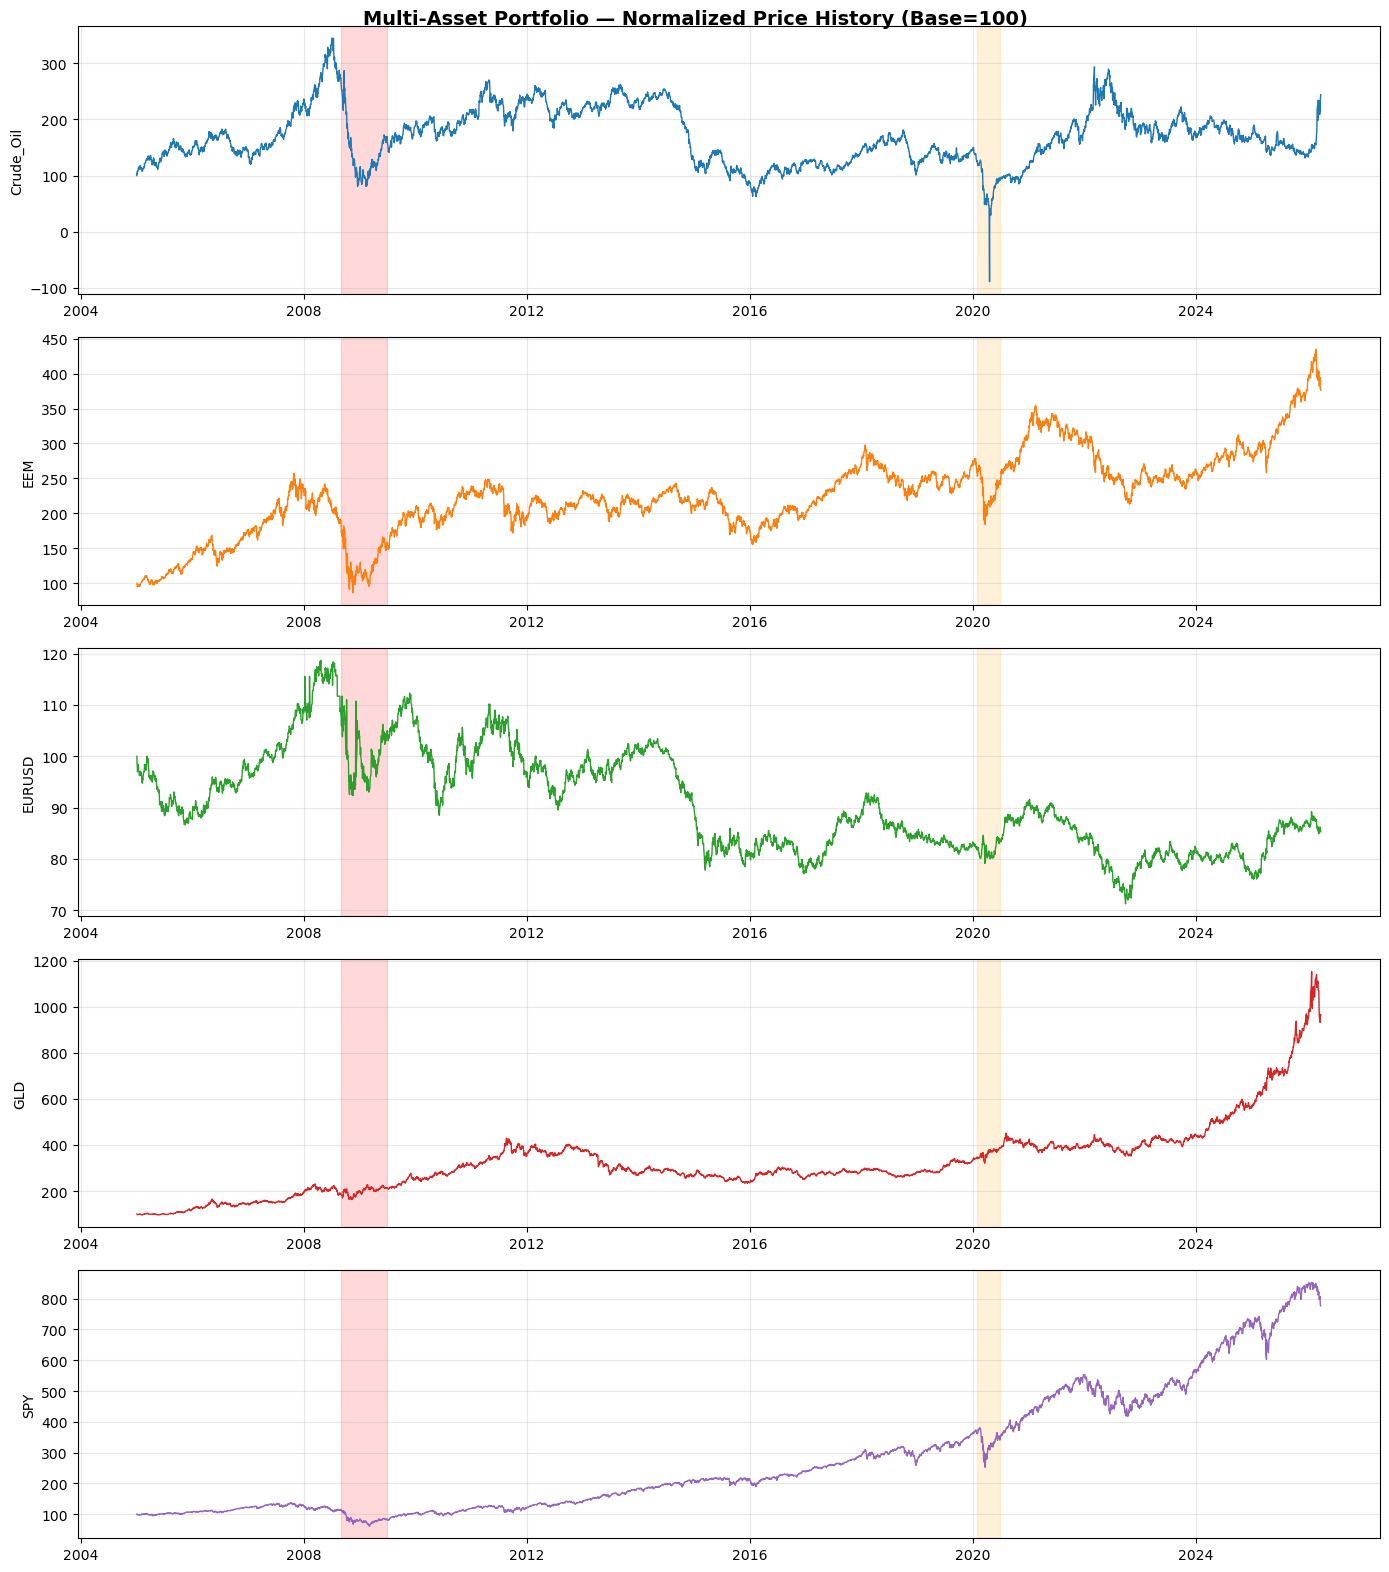

Saved: fig1_price_history.png


In [5]:
# ── 4. EDA: Price History ─────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 16))
fig.suptitle('Multi-Asset Portfolio — Normalized Price History (Base=100)', 
             fontsize=14, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for ax, col, color in zip(axes, raw_prices.columns, colors):
    normalized = raw_prices[col] / raw_prices[col].iloc[0] * 100
    ax.plot(normalized.index, normalized.values, color=color, linewidth=1)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    # Shade crisis periods
    ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'), 
               alpha=0.15, color='red', label='GFC')
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-30'),
               alpha=0.15, color='orange', label='COVID')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig1_price_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_price_history.png')

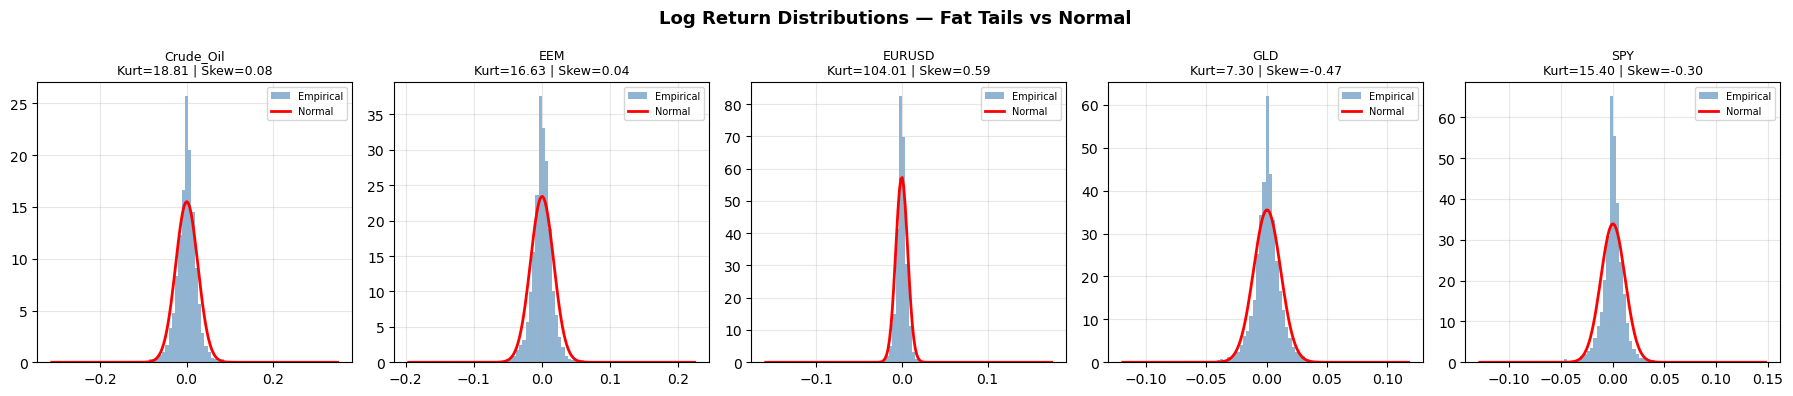

Saved: fig2_return_distributions.png


In [6]:
# ── 5. Return Distribution Analysis ──────────────────────────────────────────
from scipy import stats

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Log Return Distributions — Fat Tails vs Normal', fontsize=13, fontweight='bold')

for ax, col in zip(axes, log_returns.columns):
    r = log_returns[col].dropna()
    ax.hist(r, bins=80, density=True, alpha=0.6, color='steelblue', label='Empirical')
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 200)
    mu, sigma = r.mean(), r.std()
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal')
    kurt = stats.kurtosis(r)
    skew = stats.skew(r)
    ax.set_title(f'{col}\nKurt={kurt:.2f} | Skew={skew:.2f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig2_return_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_return_distributions.png')

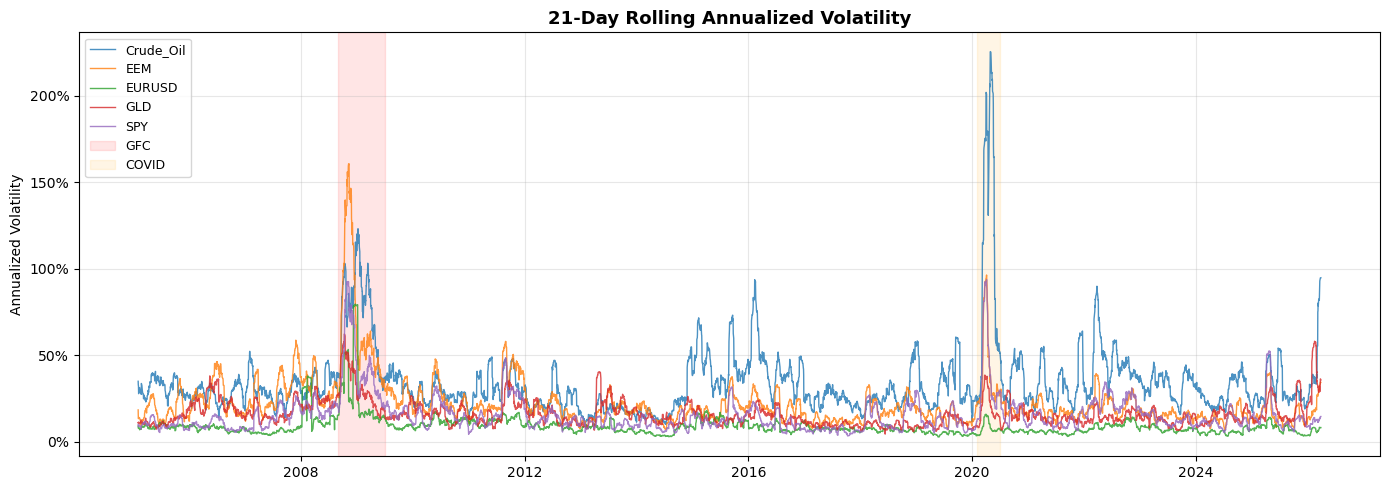

In [7]:
# ── 6. Rolling Volatility ─────────────────────────────────────────────────────
rolling_vol = log_returns.rolling(21).std() * np.sqrt(252)  # annualized

fig, ax = plt.subplots(figsize=(14, 5))
for col in rolling_vol.columns:
    ax.plot(rolling_vol.index, rolling_vol[col], linewidth=1, label=col, alpha=0.8)

ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'), 
           alpha=0.1, color='red', label='GFC')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-30'),
           alpha=0.1, color='orange', label='COVID')

ax.set_title('21-Day Rolling Annualized Volatility', fontsize=13, fontweight='bold')
ax.set_ylabel('Annualized Volatility')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig3_rolling_volatility.png'), dpi=150, bbox_inches='tight')
plt.show()

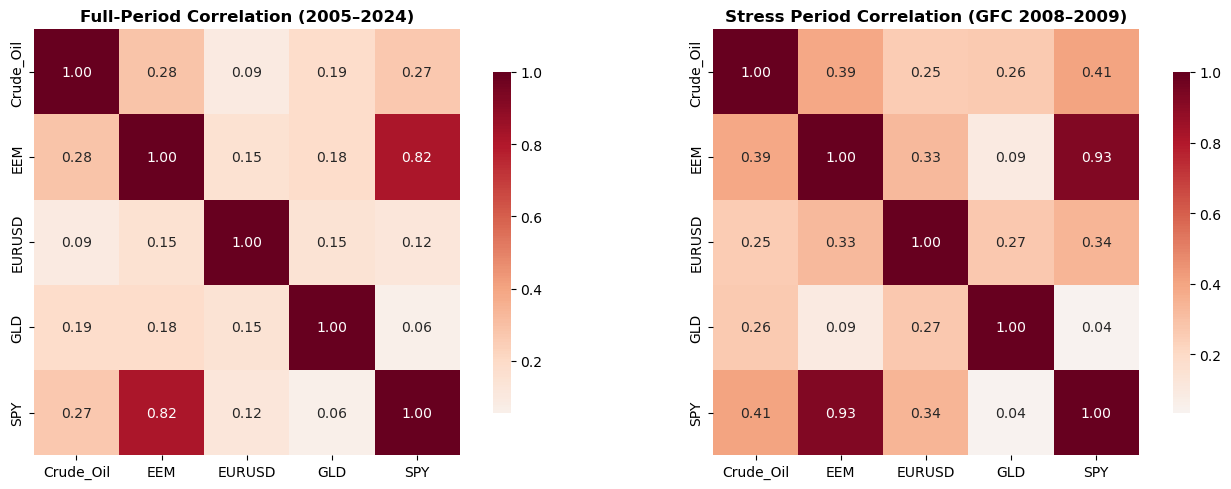

Note: Correlations tend to spike toward 1 (contagion) during crisis periods.


In [8]:
# ── 7. Correlation Analysis ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full-period correlation
corr_full = log_returns.corr()
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Full-Period Correlation (2005–2024)', fontweight='bold')

# Stress period correlation (GFC 2008–2009)
stress_mask = (log_returns.index >= '2008-09-01') & (log_returns.index <= '2009-06-30')
corr_stress = log_returns[stress_mask].corr()
sns.heatmap(corr_stress, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title('Stress Period Correlation (GFC 2008–2009)', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig4_correlation_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Note: Correlations tend to spike toward 1 (contagion) during crisis periods.')

In [9]:
# ── 8. Define Portfolio & Save Data ──────────────────────────────────────────
# Equal-weight portfolio
WEIGHTS = pd.Series({
    'SPY': 0.30,
    'GLD': 0.20,
    'EEM': 0.20,
    'EURUSD': 0.15,
    'Crude_Oil': 0.15
})

portfolio_returns = (log_returns * WEIGHTS).sum(axis=1)

print(f'Portfolio return stats:')
print(f'  Daily mean:  {portfolio_returns.mean():.6f}')
print(f'  Daily std:   {portfolio_returns.std():.6f}')
print(f'  Annualized vol: {portfolio_returns.std() * np.sqrt(252):.2%}')
print(f'  Skewness: {stats.skew(portfolio_returns):.4f}')
print(f'  Kurtosis: {stats.kurtosis(portfolio_returns):.4f}')

# Save all data
raw_prices.to_csv(os.path.join(DATA_DIR, 'raw_prices.csv'))
log_returns.to_csv(os.path.join(DATA_DIR, 'log_returns.csv'))
portfolio_returns.to_csv(os.path.join(DATA_DIR, 'portfolio_returns.csv'), header=['portfolio_return'])
macro.to_csv(os.path.join(DATA_DIR, 'macro_factors.csv'))
WEIGHTS.to_csv(os.path.join(DATA_DIR, 'portfolio_weights.csv'), header=['weight'])


Portfolio return stats:
  Daily mean:  0.000281
  Daily std:   0.009480
  Annualized vol: 15.05%
  Skewness: -0.4548
  Kurtosis: 11.8569
